### Analyse de Sentiments NLP ###

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("C:/Users/PC/Documents/nlp_sentiments/train.csv", header=None, 
                 names=["sentiment", "titre", "texte"],encoding="latin-1")

df = df.sample(50000, random_state=42)

print(df["sentiment"].unique())
print(df["sentiment"].value_counts())


[1 2]
sentiment
2    25039
1    24961
Name: count, dtype: int64


In [3]:
print(df.columns.tolist())
print(df["sentiment"].unique())
print(df["texte"].iloc[0])

['sentiment', 'titre', 'texte']
[1 2]
This product consists of a piece of thin flexible insulating material, adhesive backed velcro and white electrical tape.Problems:1. Instructions are three pictures with little more information.2. Velcro was all crumpled as received and was stronger than the adhesive. When i tried to disengage the velcro both pieces came off and the paint from the ceiling.3. White electrical tape was horrible... cheap, narrow and it fell off in less than 1 hour.4. The price is a ripoff.I am building my own which is easier to use, cheaper, more attractive, and higher r-value. I am surprised Amazon even lists this junk.


In [4]:
#je convertis le sentiment en binaire lisible
df["sentiment"] = df["sentiment"].map({1: "negative", 2: "positive"})
print(df["sentiment"].value_counts())

#supprimer les lignes sans texte
df = df.dropna(subset=["texte"])
print(f"lignes apres dropna: {len(df)}")

#voir la longueur des texte
df["longueur"] = df["texte"].str.len()
print(df["longueur"].describe())


sentiment
positive    25039
negative    24961
Name: count, dtype: int64
lignes apres dropna: 50000
count    50000.000000
mean       405.501820
std        234.369908
min         25.000000
25%        208.000000
50%        356.000000
75%        566.000000
max       1005.000000
Name: longueur, dtype: float64


In [5]:
print(df["sentiment"].dtype)
print(df["sentiment"].iloc[0])
print(type(df["sentiment"].iloc[0]))
print(df["sentiment"].unique())

object
negative
<class 'str'>
['negative' 'positive']


In [6]:
import re

def nettoyer_texte(texte):
    texte = str(texte).lower() #mettre en miniscule le texte
    texte = re.sub(r'http\S+', '', texte)  #supprime les urls 
    texte = re.sub(r'@\W+', '', texte) #supprime les mentions
    texte = re.sub(r'#\W+', '', texte) #supprime les hastags
    texte = re.sub(r'[^a-z\s]', ' ', texte) #garde les lettres
    texte = re.sub(r'\s+', ' ', texte).strip() #supprime les espace multiples

    return texte


#Appliquer la donction
df["texte_clean"] = df["texte"].apply(nettoyer_texte)

print(df["texte_clean"].iloc[0])
print(df[["texte", "texte_clean"]].head(3))

this product consists of a piece of thin flexible insulating material adhesive backed velcro and white electrical tape problems instructions are three pictures with little more information velcro was all crumpled as received and was stronger than the adhesive when i tried to disengage the velcro both pieces came off and the paint from the ceiling white electrical tape was horrible cheap narrow and it fell off in less than hour the price is a ripoff i am building my own which is easier to use cheaper more attractive and higher r value i am surprised amazon even lists this junk
                                                     texte  \
2079998  This product consists of a piece of thin flexi...   
1443106  Even on the lowest setting, the toast is too d...   
3463669  I enjoyed this disc. The video is stunning. I ...   

                                               texte_clean  
2079998  this product consists of a piece of thin flexi...  
1443106  even on the lowest setting the toast 

## Visualisations

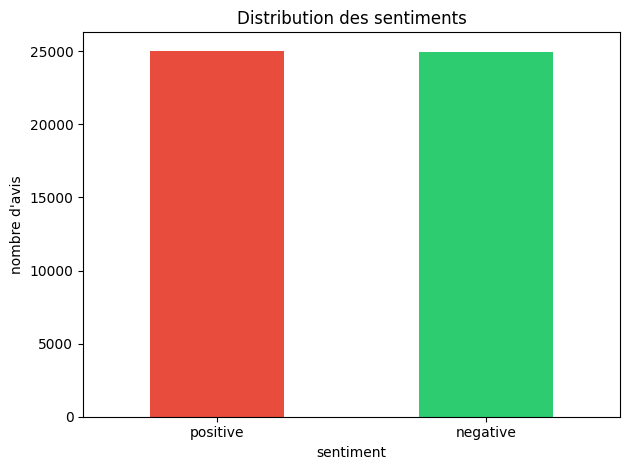

In [7]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar", color=["#E74C3C", "#2ECC71"])
plt.title("Distribution des sentiments")
plt.xlabel("sentiment")
plt.ylabel("nombre d'avis")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


##-Longueur des textes par sentiments

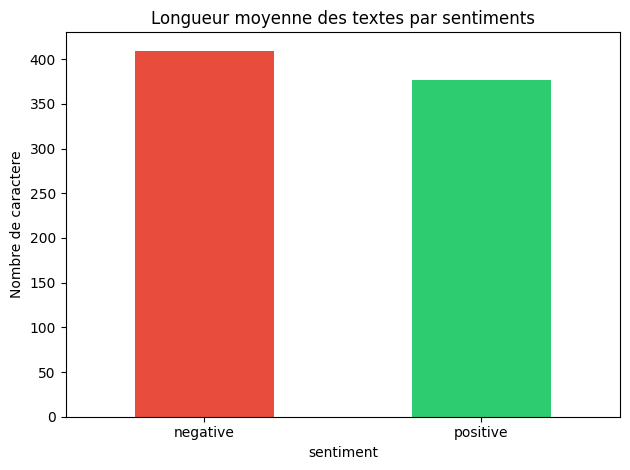

In [8]:
df["longueur"] = df["texte_clean"].str.len()

df.groupby("sentiment")["longueur"].mean().plot(kind="bar", color=["#E74C3C", "#2ECC71"])
plt.title("Longueur moyenne des textes par sentiments")
plt.ylabel("Nombre de caractere")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

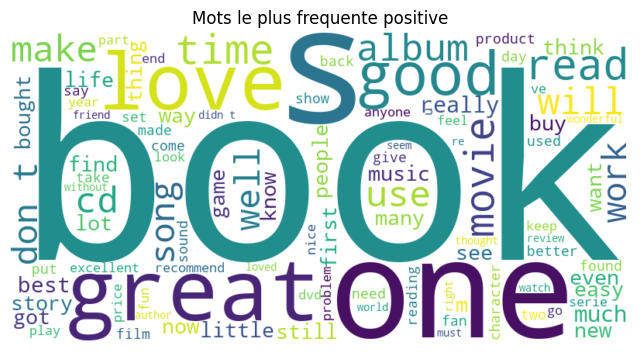

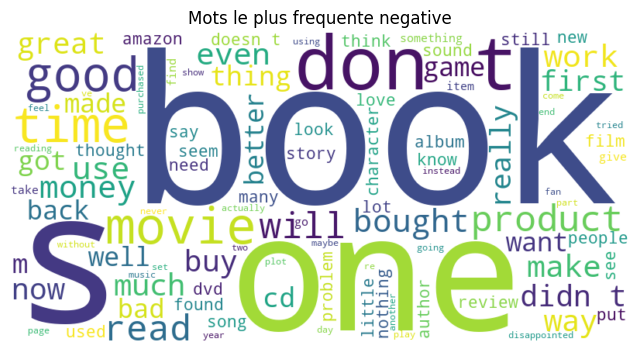

In [9]:
from wordcloud import WordCloud

for sentiment in ["positive", "negative"]:
    textes = " ".join(df[df["sentiment"]==sentiment]["texte_clean"])
    wc = WordCloud(width=800, height=400,
                   background_color='white',
                   max_words=100).generate(textes)
    plt.figure(figsize=(8,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Mots le plus frequente {sentiment}")
    plt.show()

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline

#Split 
X = df["texte_clean"]
y = df["sentiment"]

X_train, X_test, y_train ,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(f"Train : {len(X_train)} | Test: {len(X_test)} ")

#Comaparaison des modeles
modeles = {
    "LogisticRegression" : LogisticRegression(max_iter=1000),
    "LinearSVC" : LinearSVC(),
    "MultinomialNB" : MultinomialNB(),
    "RandomForest" : RandomForestClassifier(n_estimators=100,max_depth=20, random_state=42, n_jobs=-1)
}

resultats = []
for nom, modele in modeles.items():
    pipe = Pipeline([
    ("tfidf",  TfidfVectorizer(max_features=5000, ngram_range=(1,2))),  # ← f après Tfid
    ("modele", modele)
])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    resultats.append({
        "modele" : nom,
        "Accuracy" : round(accuracy_score(y_test, y_pred),4),
        "F1" : round(f1_score(y_test, y_pred, pos_label="positive"), 4)
    })

df_res = pd.DataFrame(resultats).sort_values("Accuracy",ascending=False)
print(df_res.to_string(index=False))



Train : 40000 | Test: 10000 
            modele  Accuracy     F1
LogisticRegression    0.8736 0.8733
         LinearSVC    0.8708 0.8709
     MultinomialNB    0.8456 0.8459
      RandomForest    0.8016 0.8068


In [13]:
# ══════════════════════════════════════
# CONCLUSIONS DU NOTEBOOK
# ══════════════════════════════════════

print("=" * 50)
print("  CONCLUSIONS :Projet NLP Sentiments")
print("=" * 50)

print(f"""
Dataset    : 50 000 avis Amazon
Classes    : positive ({df['sentiment'].value_counts()['positive']}) 
             negative ({df['sentiment'].value_counts()['negative']})
Equilibre  : OUI 

Meilleur modele  : LogisticRegression
Accuracy         : 87.36%
F1 Score         : 87.33%

Parametres retenus pour train.py :
  - TfidfVectorizer(max_features=5000, ngram_range=(1,2))
  - LogisticRegression(max_iter=1000)
  - text_col = 'texte'
  - target   = 'sentiment'
""")


  CONCLUSIONS :Projet NLP Sentiments

Dataset    : 50 000 avis Amazon
Classes    : positive (25039) 
             negative (24961)
Equilibre  : OUI 

Meilleur modele  : LogisticRegression
Accuracy         : 87.36%
F1 Score         : 87.33%

Parametres retenus pour train.py :
  - TfidfVectorizer(max_features=5000, ngram_range=(1,2))
  - LogisticRegression(max_iter=1000)
  - text_col = 'texte'
  - target   = 'sentiment'

